# TODO:
* [x] move lattice code to class
* [x] add determination of specializer/generalizer; check implementation of specializer
* [ ] improve projection
* [ ] use KNN graph or graph from umap
* [x] Set color to scenario ID
* [x] Compute number of generalizers needed so that at least k specailizers exist per feature
* [x] Function to determine best specialization
* [x] Weighted sum instead of minimax for generalizers; may be z-score normalize before weighted sum?; maybe show weighed sum as percentile?
* [x] use z-score or rank in PCP

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [12]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

# EDA Alternatives / Baselines

In [13]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

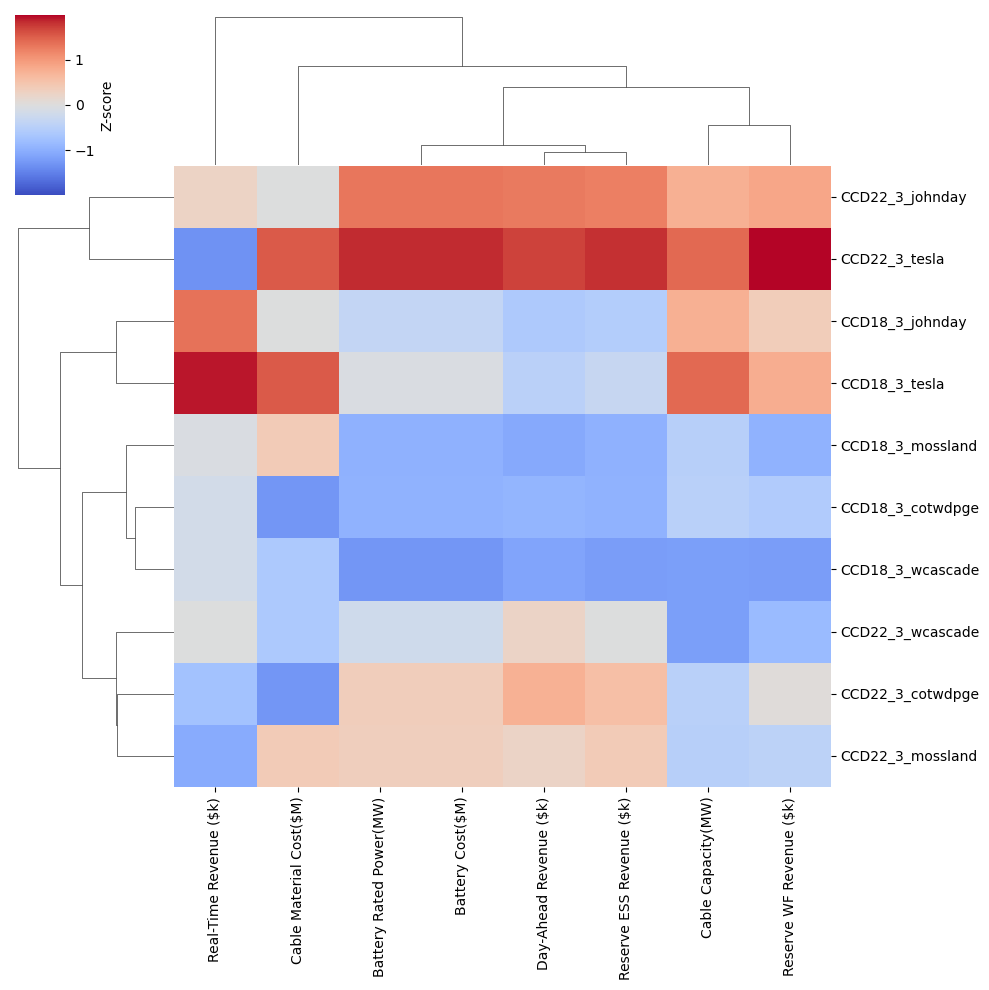

In [14]:
import seaborn as sns

df = df_design

X = (df - df.mean())/df.std()
vmax = vmax = X.abs().max().max()
vmin = -vmax
sns.clustermap(X, vmin=vmin, vmax=vmax, cmap='coolwarm', cbar_kws=dict(label='Z-score'))

# import matplotlib
# matplotlib.figure.Figure.colorbar.

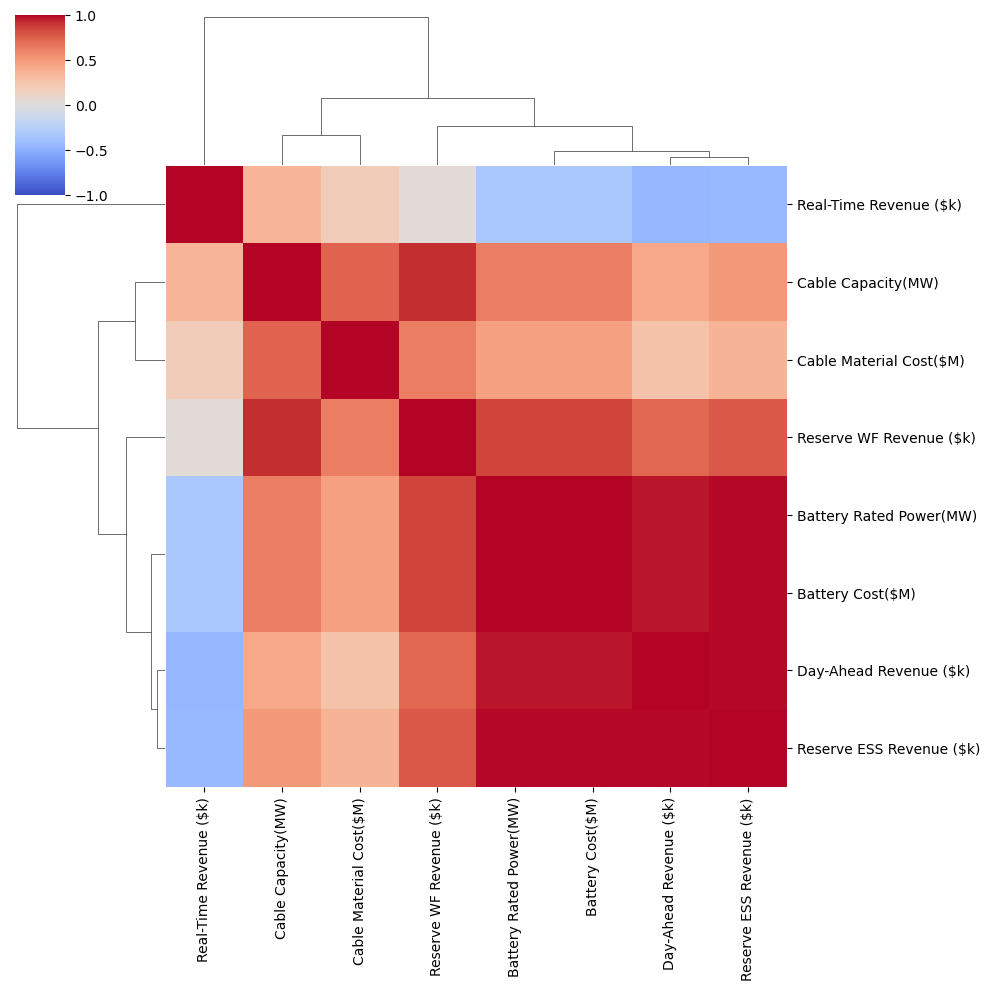

In [15]:
C = df.corr()
vmax = C.abs().max().max()
sns.clustermap(C, vmin=-vmax, vmax=vmax, cmap='coolwarm')

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:2433: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(8.878187942504884, 11.750447463989257, 10.373489141464233, 12.73018765449524)

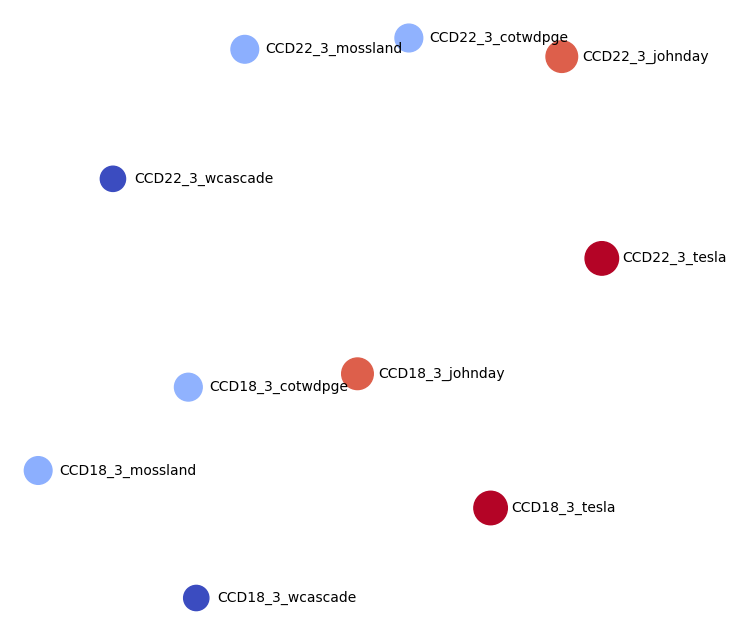

In [16]:
from umap import UMAP

by = df.columns[0]

plt.figure(figsize=(8, 8))

cmap = plt.cm.coolwarm
norm = plt.Normalize(-vmax, vmax)

pos = UMAP().fit_transform(X)
plt.scatter(*pos.T, s=df[by]/5, c=cmap(norm(X[by])))

for s, xy in zip(df.index, pos):
    plt.annotate(s, xy, va='center', xytext=(15, 0), textcoords='offset points')

plt.axis('off')


Cable Material Cost($M):  less --> more


<Figure size 800x800 with 0 Axes>

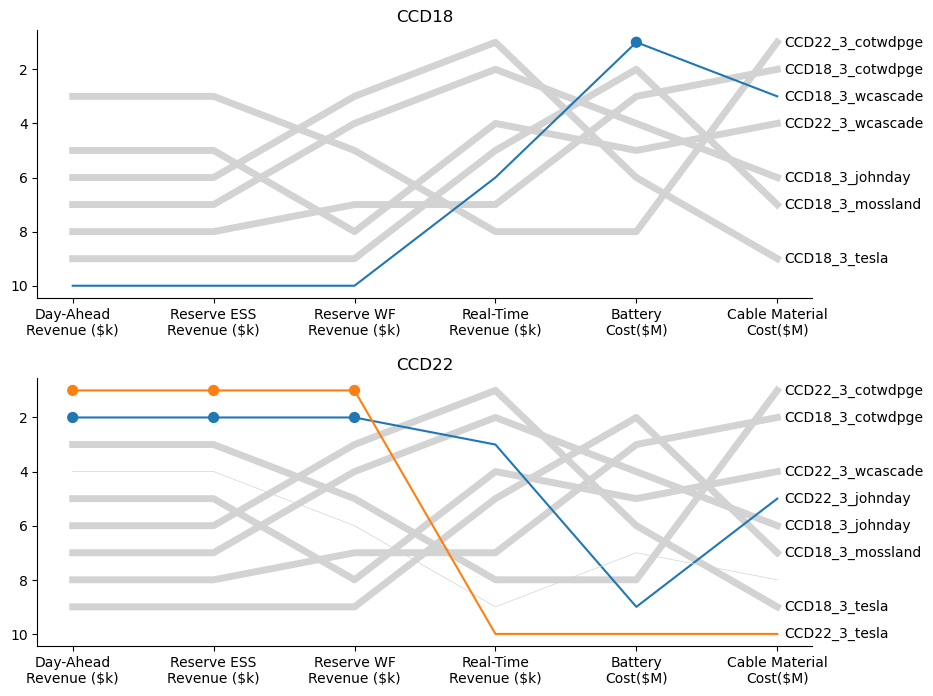

In [17]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    max_specializers=2,
    # min_specializers=1,
    # n_generalizers=1,
)

by = ovars[0]

# plt.figure(figsize=(8, 8))
# plt.axis('off')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold'),
#     show_negative=True,
#     show_positive=False,
# )

# plt.title(f'{by}:  less --> more')
print(f'{by}:  less --> more')
plt.savefig('design_solutions_tradeoffs_v0.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.3)
# self.ovars_formatted()

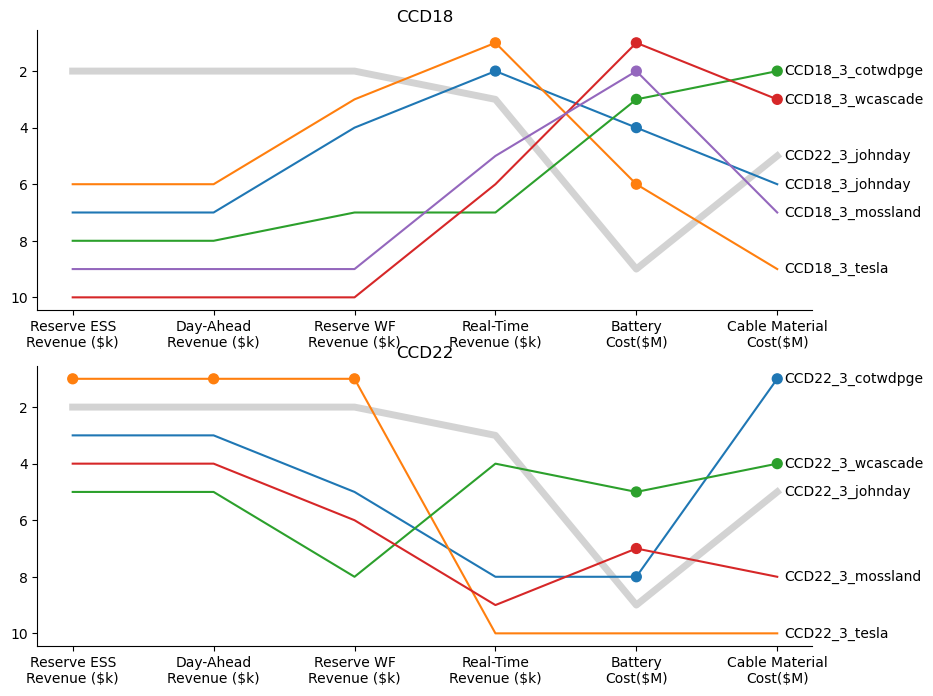

In [18]:
# Weighted Sum Version

scale = pd.Series(1, ovars)
scale[ascending] = -1 # penalize high cost with negative weight
weights = scale/(df[ovars].mean())

score = -(df[ovars]*weights).sum(axis=1)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    # max_specializers=1,
    min_specializers=1,
    # n_generalizers=5,
    score=score
)

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

Cable Material Cost($M):  less --> more


<Figure size 800x800 with 0 Axes>

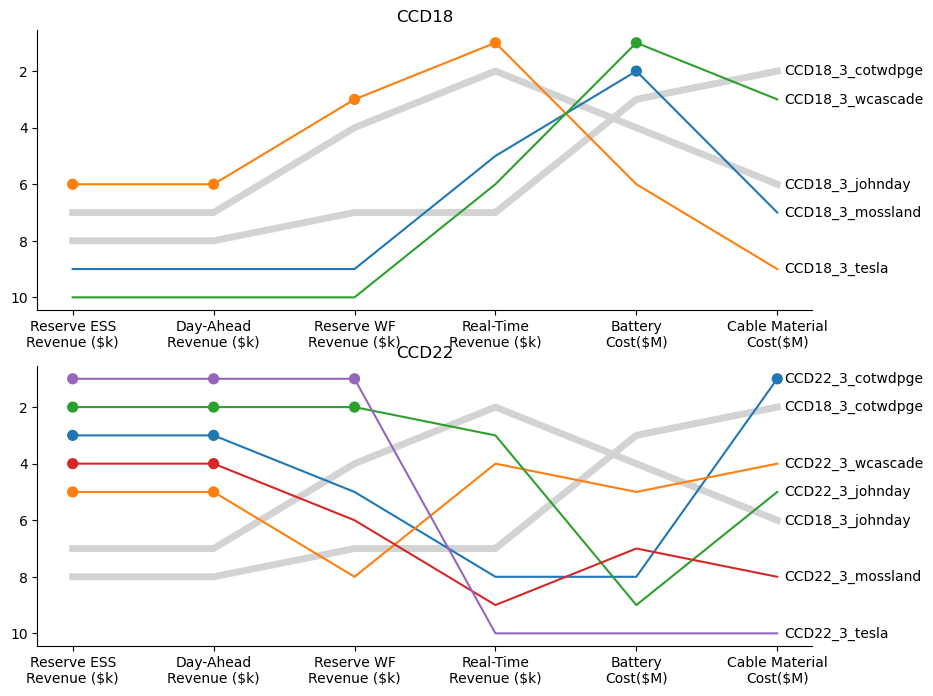

In [19]:
self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    # max_specializers=2,
    min_specializers=1,
    # n_generalizers=1,
)

by = ovars[0]

# plt.figure(figsize=(8, 8))
# plt.axis('off')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold'),
#     show_negative=True,
#     show_positive=False,
# )

# plt.title(f'{by}:  less --> more')
print(f'{by}:  less --> more')
plt.savefig('design_solutions_tradeoffs_v0.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

# Larger Example

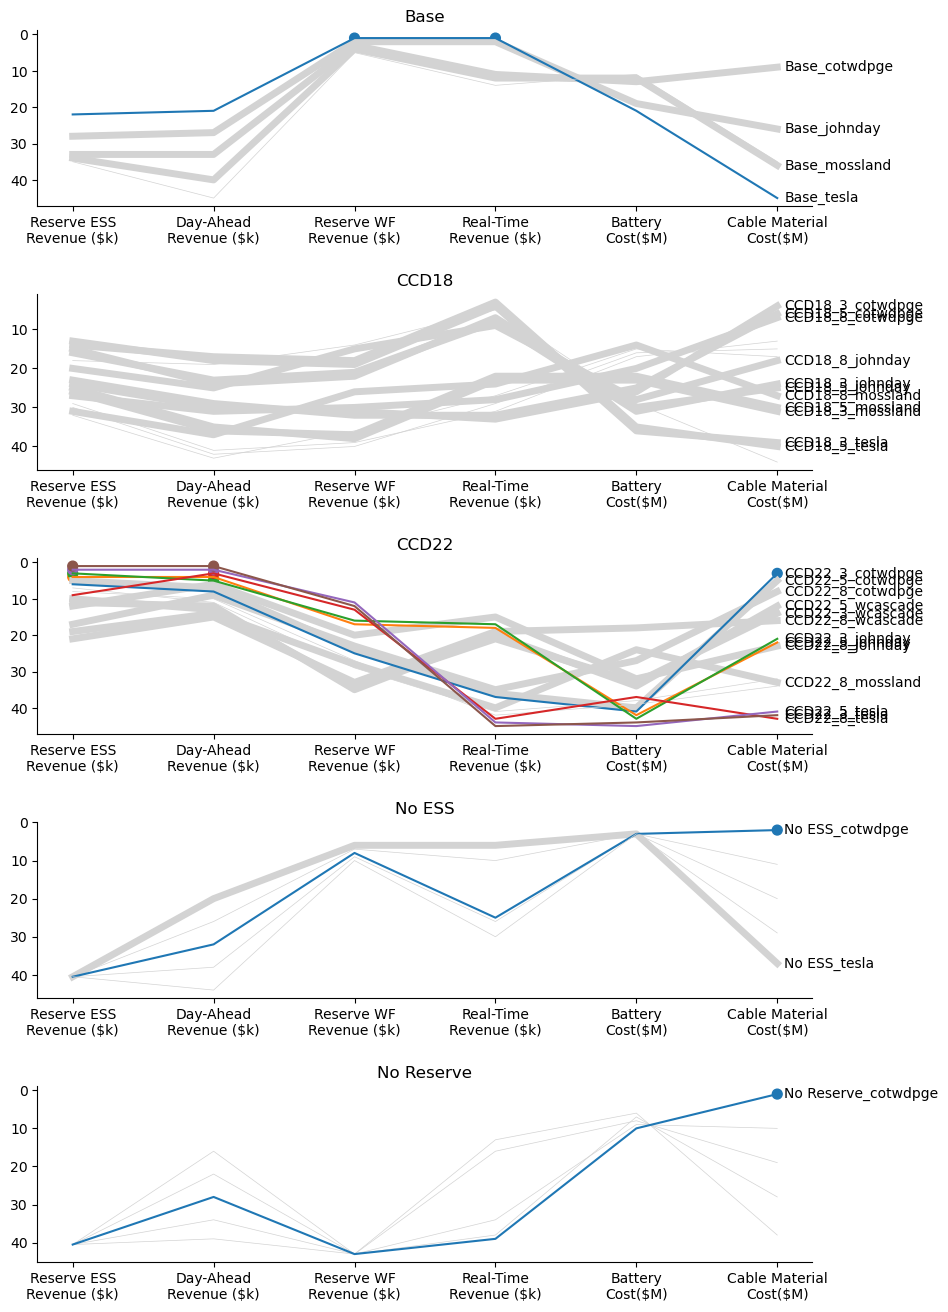

In [20]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=0)

def get_cluster_name(s):
    parts = s.split('_')
    return '_'.join([parts[0], parts[-1]])
    
ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = list(set(df_design.columns).difference(ovars))

self = tl.DirectTradeoffLattice(
    df_design,
    ovars, dvars,
    ascending=ascending,
    max_specializers=5,
    # min_specializers=1,
    # n_generalizers=10,
)

by = ovars[0]

# plt.figure(figsize=(12, 24))
# plt.axis('off')
# plt.title(f'{by}:  less --> more')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold')
# )

# plt.savefig('design_solutions_tradeoffs.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 16))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.5)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1393: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))


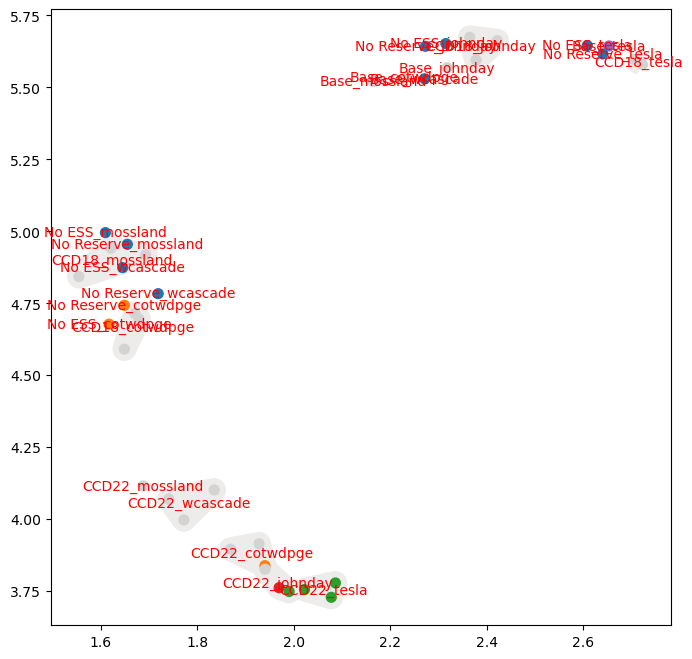

In [21]:
from matplotlib.colors import to_rgb

umap_kwargs = dict(
    # n_neighbors=10,
    spread=.15,
)

self = tl.DirectTradeoffLattice(
    df_design,
    ovars, dvars,
    ascending=ascending,
    # max_specializers=5,
    min_specializers=1,
    # n_generalizers=10,
)

def get_facet(s):
    parts = s.split('_')
    return f'{parts[0]}_{parts[-1]}'

facet = pd.Series(
    map(get_facet, self.df.index),
    index=self.df.index
)

mask = np.array(
    self.df.index.map(
        set(self.specializers.index)\
            .union(self.generalizers)\
            .__contains__
    )
)

# 

default_color = (*to_rgb('lightgray'), 1.0)

cdict = {
    k: plt.cm.tab10(i)
    for i, k in enumerate(self.specialization.unique())
}

data = pd.DataFrame(
    UMAP(**umap_kwargs).fit_transform(self.df[mask]),
    index=self.df.index[mask],
    columns=['x', 'y']
)

# smin = 5
# smax = 50
# data['s'] = (smax - smin)*mask + smin

data['c'] = [
    cdict[self.specialization[i]] if i in self.specialization else default_color
    for i in data.index
]

import vis; reload(vis)

vis.get_cluster_hulls(
    X=data[['x', 'y']],
    y=facet[mask],
    cluster_label_prefix='',
    marker_size=50,
    marker_color=data['c']
)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1393: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))


CPU times: user 1.29 s, sys: 93.8 ms, total: 1.38 s
Wall time: 1.79 s


(24.99779, 187.14021, -12.239999999999998, 336.23999999999995)

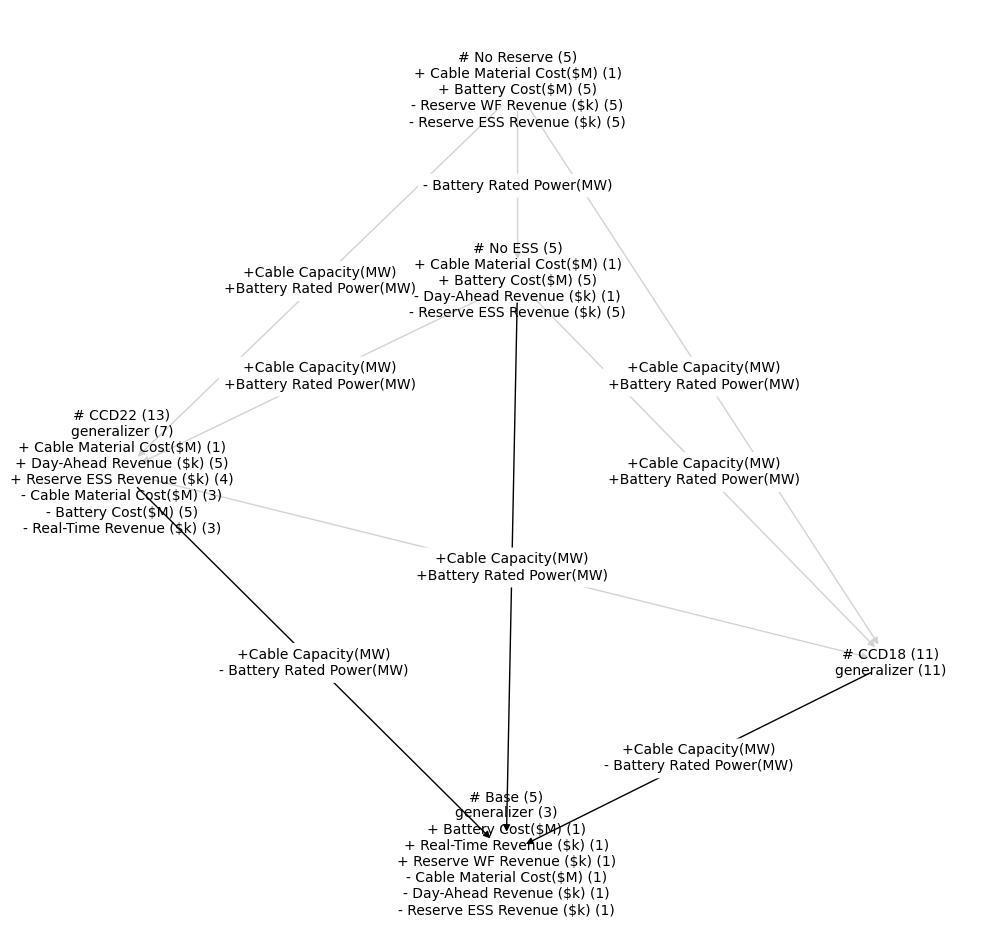

In [22]:
%%time

import networkx as nx

import tradeoff_lattice; reload(tradeoff_lattice)
from tradeoff_lattice import get_triangulation, test_all, TradeoffLattice

class ClusteredTradeoffLattice(TradeoffLattice):
    def __init__(self, *args, cluster=None, all_points=False, **kwargs):
        super().__init__(*args, **kwargs)

        self.X = self.df
        if not all_points:
            mask = np.array(
                self.df.index.map(
                    set(self.specializers.index)\
                        .union(self.generalizers)\
                        .__contains__
                )
            )
            self.X = self.df[mask]

        xy = pd.DataFrame(
            UMAP(**umap_kwargs).fit_transform(self.X),
            index=self.X.index,
            columns=['x', 'y']
        )

        grouped = xy.groupby(cluster.loc[self.X.index])

        self.centroids = grouped.mean()
    
        self.G = nx.relabel_nodes(
            get_triangulation(self.centroids.values),
            dict(enumerate(self.centroids.index))
        )

        for k, dfk in grouped:
            self.G.nodes[k]['index'] = dfk.index
        
        for u, v, d in self.G.edges(data=True):
            d['test'] = test_all(
                self.X.loc[self.G.nodes[u]['index']],
                self.X.loc[self.G.nodes[v]['index']],
            )

    def get_rows(self, v, df):
        index = self.G.nodes[v]['index']
        return df.loc[df.index.intersection(index)]
    
    def get_node_label(self, v):
        index = self.G.nodes[v]['index']

        yield f'# {v} ({len(index)})'
        
        gv = self.generalizers.intersection(index)
        if len(gv):
            yield f'generalizer ({len(gv)})'

        for key, value in self.get_rows(v, self.specializers).sum(axis=0).items():
            if value > 0:
                yield f'+ {key} ({value})'

        for key, value in self.get_rows(v, self.anti_specializers).sum(axis=0).items():
            if value > 0:
                yield f'- {key} ({value})'





def get_design_and_location(s):
    parts = s.split('_')
    return f'{parts[0]}_{parts[-1]}'

def get_design(s):
    return s.split('_')[0]

get_facet = get_design

cluster = pd.Series(
    map(get_facet, df_design.index),
    index=df_design.index
)

self = ClusteredTradeoffLattice(
    df_design,
    ovars, dvars,
    cluster=cluster,
    ascending=ascending,
    # max_specializers=5,
    min_specializers=1,
    # n_generalizers=10,
)

plt.figure(figsize=(12, 12))
self.draw(
    by=ovars[0], alpha=0.5, with_edge_labels=dvars,
    show_negative=True,
    show_positive=True,
    edge_labels_kwargs=dict(rotate=False)
)

plt.axis('off')